# Spatial MRV Maps And Reports

This notebook turns the processed ERW/SCEPTER outputs into map-ready and report-ready products. It starts after `06_extract_scepter_outputs.ipynb`, using spatial model-unit results joined back to ESA cropland raster-block geometries.

The purpose is to produce clear MRV deliverables: scenario comparison tables, spatial maps, AOI-level summaries, and a short Markdown report that records what was mapped, which ESA/HWSD2/CHIRPS inputs were used, and which SCEPTER outputs are still missing.


## Workflow

1. **Load spatial SCEPTER results** from `data/scepter_runs/outputs/extracted/scepter_results_by_model_unit.gpkg`.
2. **Validate provenance** from notebooks `04-06`: ESA cropland source, HWSD2 soil-map/defaults, CHIRPS rainfall, and runoff note.
3. **Choose MRV metrics** such as DIC-derived CO2 equivalent, carbon equivalent, cumulative CO2 removal, or carbon retained when present.
4. **Build scenario comparison tables** for baseline and ERW scenarios.
5. **Create map layers** for each scenario and each available MRV metric; if no metric exists, map result status only.
6. **Write map images and vector layers** for reports and GIS review.
7. **Write a Markdown report** summarizing inputs, status, metrics, outputs, and next decisions.

If SCEPTER has not been executed yet, this notebook still produces a status report showing that result summaries are missing. Once SCEPTER outputs exist, rerun notebooks `06` and `07` to produce quantitative MRV maps.


In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

def mount_google_drive_if_colab() -> None:
    try:
        from google.colab import drive
    except ModuleNotFoundError:
        return

    drive.mount("/content/drive")


mount_google_drive_if_colab()

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
COLAB_DATA_ROOT = COLAB_PROJECT_ROOT / "data"
LOCAL_PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()


def has_erw_package(project_root: Path) -> bool:
    return (project_root / "src" / "erw_mrv" / "__init__.py").exists()


def source_root_candidates() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [LOCAL_PROJECT_ROOT, COLAB_PROJECT_ROOT]
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "erw_spatial_mrv"))
    candidates.extend(
        Path(path)
        for path in (
            "/content/erw_spatial_mrv",
            "/content/enhanced_rock_weathering/erw_spatial_mrv",
            "/content/drive/MyDrive/erw_spatial_mrv",
        )
    )
    unique = []
    for candidate in candidates:
        if candidate not in unique:
            unique.append(candidate)
    return unique


def find_source_project_root() -> Path:
    for candidate in source_root_candidates():
        if has_erw_package(candidate):
            return candidate
    checked = chr(10).join(f"- {candidate}" for candidate in source_root_candidates())
    raise ModuleNotFoundError(
        "Could not find src/erw_mrv. The data can live in Google Drive, but "
        "the notebook still needs the project source folder containing src/erw_mrv. "
        "In Colab, upload/sync the full erw_spatial_mrv project or run from a "
        "checkout that includes src/. Checked: "
        f"{checked}"
    )


SOURCE_PROJECT_ROOT = find_source_project_root()
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_DATA_ROOT.exists() else SOURCE_PROJECT_ROOT
DATA_ROOT = COLAB_DATA_ROOT if COLAB_DATA_ROOT.exists() else PROJECT_ROOT / "data"
os.environ["ERW_MRV_DATA_ROOT"] = str(DATA_ROOT)

SRC = SOURCE_PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SOURCE_PROJECT_ROOT = {SOURCE_PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")

from erw_mrv.paths import (
    OUTPUT_FIGURES,
    OUTPUT_MAPS,
    OUTPUT_REPORTS,
    OUTPUT_TABLES,
    SCEPTER_OUTPUTS,
    ensure_dir,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
plt.rcParams["figure.figsize"] = (10, 8)


PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
SOURCE_PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
DATA_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data


## Configure Inputs And Outputs


In [2]:
EXTRACTED_DIR = SCEPTER_OUTPUTS / "extracted"
SPATIAL_RESULTS_PATH = EXTRACTED_DIR / "scepter_results_by_model_unit.gpkg"
RESULTS_TABLE_PATH = EXTRACTED_DIR / "scepter_results_long.csv"
SCENARIO_SUMMARY_PATH = EXTRACTED_DIR / "scepter_scenario_summary.csv"
ADDITIONALITY_PATH = EXTRACTED_DIR / "scepter_additionality.csv"
AOI_PATH = DATA_ROOT / "processed" / "boundaries" / "selected_districts_aoi.geojson"

MAP_DIR = ensure_dir(OUTPUT_MAPS / "spatial_mrv")
FIGURE_DIR = ensure_dir(OUTPUT_FIGURES / "spatial_mrv")
TABLE_DIR = ensure_dir(OUTPUT_TABLES / "spatial_mrv")
REPORT_DIR = ensure_dir(OUTPUT_REPORTS / "spatial_mrv")

required = [SPATIAL_RESULTS_PATH, RESULTS_TABLE_PATH]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing notebook 06 output(s). Run notebook 06 first. Missing: "
        + "; ".join(str(path) for path in missing)
    )

MAP_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR


(PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/figures/spatial_mrv'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/tables/spatial_mrv'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/reports/spatial_mrv'))

## Load Results


In [3]:
spatial_results = gpd.read_file(SPATIAL_RESULTS_PATH)
aoi_boundary = gpd.read_file(AOI_PATH).to_crs(spatial_results.crs)
results = pd.read_csv(RESULTS_TABLE_PATH)
scenario_summary = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
additionality = pd.read_csv(ADDITIONALITY_PATH) if ADDITIONALITY_PATH.exists() else pd.DataFrame()

required_provenance_columns = [
    "cropland_source",
    "cropland_source_path",
    "soil_map_texture_group",
    "soil_map_source_path",
    "soil_source",
    "rainfall_source",
    "rainfall_months_used",
    "runoff_note",
]
missing_provenance = [column for column in required_provenance_columns if column not in spatial_results.columns]
if missing_provenance:
    raise ValueError(
        "Spatial MRV results are missing notebook 04-06 provenance columns. "
        "Rerun notebooks 04, 05, and 06 before report generation. Missing: "
        f"{missing_provenance}"
    )

missing_provenance_values = spatial_results[required_provenance_columns].isna().sum()
missing_provenance_values = missing_provenance_values[missing_provenance_values > 0]
if not missing_provenance_values.empty:
    raise ValueError(f"Required provenance columns contain missing values: {missing_provenance_values.to_dict()}")

print(f"Spatial result rows: {len(spatial_results):,}")
print(f"Flat result rows: {len(results):,}")
print(f"Scenarios: {spatial_results['scenario_id'].nunique() if 'scenario_id' in spatial_results.columns else 0:,}")
print("Cropland source:", spatial_results["cropland_source"].dropna().astype(str).iloc[0])
print("Soil map labels:", sorted(spatial_results["soil_map_texture_group"].dropna().astype(str).unique()))
print("Rainfall months:", spatial_results["rainfall_months_used"].dropna().astype(str).iloc[0])
print(f"AOI boundary loaded: {AOI_PATH}")
spatial_results.head()


Spatial result rows: 400
Flat result rows: 400
Scenarios: 4
Cropland source: ESA WorldCover cropland mask
Soil map labels: ['Clay', 'Clay loam', 'Loam']
Rainfall months: 2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12
AOI boundary loaded: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/boundaries/selected_districts_aoi.geojson


,model_unit_id,value,source,cropland_block_id,cropland_area_m2,cropland_area_ha,area_m2,area_ha,centroid_lon,centroid_lat,soil_ph,cec_cmolc_kg,clay_pct,bulk_density_g_cm3,soil_depth_cm,temperature_c,precipitation_mm_yr,runoff_mm_yr,basalt_application_t_ha,basalt_d50_um,simulation_years,block_geometry_area_m2,soil_map_texture_usda,soil_map_texture_soter,missing_requested_months,run_id,scenario_id,execution_status,summary_path,input_status,cropland_source,cropland_source_path,cropland_pixels,cropland_pixel_area_m2,cropland_area_note,soil_map_hwsd2_unit_id,soil_map_texture_group,soil_map_wrb4,soil_map_fao90,soil_map_clay_pct,soil_map_sand_pct,soil_map_silt_pct,soil_map_source_path,soil_map_join,soil_source,soil_source_path,soil_note,rainfall_source,rainfall_source_path,rainfall_months_used,runoff_note,result_status,adapter_status,return_code,elapsed_seconds,stdout_log,stderr_log,ttot_years,fdust_g_m2_yr,taudust_years,...,scepter_final_int_ALK_res,scepter_final_int_hco3_time,scepter_final_int_hco3_tflx,scepter_final_int_hco3_adv,scepter_final_int_hco3_dif,scepter_final_int_hco3_rain,scepter_final_int_hco3_inrt,scepter_final_int_hco3_g2,scepter_final_int_hco3_res,scepter_final_int_co3_time,scepter_final_int_co3_tflx,scepter_final_int_co3_adv,scepter_final_int_co3_dif,scepter_final_int_co3_rain,scepter_final_int_co3_inrt,scepter_final_int_co3_g2,scepter_final_int_co3_res,scepter_final_int_co2aq_time,scepter_final_int_co2aq_tflx,scepter_final_int_co2aq_adv,scepter_final_int_co2aq_dif,scepter_final_int_co2aq_rain,scepter_final_int_co2aq_inrt,scepter_final_int_co2aq_g2,scepter_final_int_co2aq_res,scepter_final_int_co2g_time,scepter_final_int_co2g_tflx,scepter_final_int_co2g_adv,scepter_final_int_co2g_dif,scepter_final_int_co2g_rain,scepter_final_int_co2g_inrt,scepter_final_int_co2g_g2,scepter_final_int_co2g_res,dic_flux_co2_equivalent_t,dic_flux_carbon_equivalent_t,scepter_final_int_DIC_cao,scepter_final_int_DIC_mgo,scepter_final_int_DIC_na2o,scepter_final_int_DIC_k2o,scepter_final_int_ALK_cao,scepter_final_int_ALK_mgo,scepter_final_int_ALK_na2o,scepter_final_int_ALK_k2o,scepter_final_int_hco3_cao,scepter_final_int_hco3_mgo,scepter_final_int_hco3_na2o,scepter_final_int_hco3_k2o,scepter_final_int_co3_cao,scepter_final_int_co3_mgo,scepter_final_int_co3_na2o,scepter_final_int_co3_k2o,scepter_final_int_co2aq_cao,scepter_final_int_co2aq_mgo,scepter_final_int_co2aq_na2o,scepter_final_int_co2aq_k2o,scepter_final_int_co2g_cao,scepter_final_int_co2g_mgo,scepter_final_int_co2g_na2o,scepter_final_int_co2g_k2o,geometry
0,mu_00001,1,cropland_raster_block,block_r14336_c13824,13863100.0,1386.31,13863100.0,1386.31,31.569750,1.085833,6.2,14.0,27.87396,1.3,30.0,24.0,1132.252213,283.063053,20.0,50.0,10,0.00182,9.0,M,nan,mu_00001__baseline_no_erw,baseline_no_erw,complete,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00001__baseline_no_erw/mu_00001__baseline_no_er...,esa_cropland_block_with_hwsd2_soil_map_chirps_rainfall_runoff_estimate,ESA WorldCover cropland mask,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_cdr_ugagric/data/processed/landuse_landcover/ug_agric_21landuse.tif,138631,100.0,geographic raster; used ESA WorldCover nominal 10 m pixel area,27462,Loam,FLdy,FLd,23,49,28,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_types.geojson,representative_point_within_hwsd2_aoi_soil_type,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_mdb_HWSD2_LAYERS.csv,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/scepter_soil_defaults_hwsd2.csv,AOI pixel-share weighted HWSD2 defaults for first-pass SCEPTER staging,CHIRPS rainfall_chirps_monthly via DE Africa S3,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/climate/rainfall/monthly_rainfall_aoi_

## Map Styling Helpers

These helpers keep the AOI boundary visible on all spatial outputs. The colored blocks are ESA cropland model units; the black outline is the AOI boundary from the selected districts layer.


In [4]:
def add_aoi_boundary(ax, linewidth=1.4):
    aoi_boundary.boundary.plot(ax=ax, color="black", linewidth=linewidth, zorder=10)


def finish_map(ax, title):
    add_aoi_boundary(ax)
    ax.set_title(title)
    ax.set_axis_off()


## Preview Spatial Features

This quick preview shows a small sample of the model-unit/result geometries and key attributes before creating scenario maps.

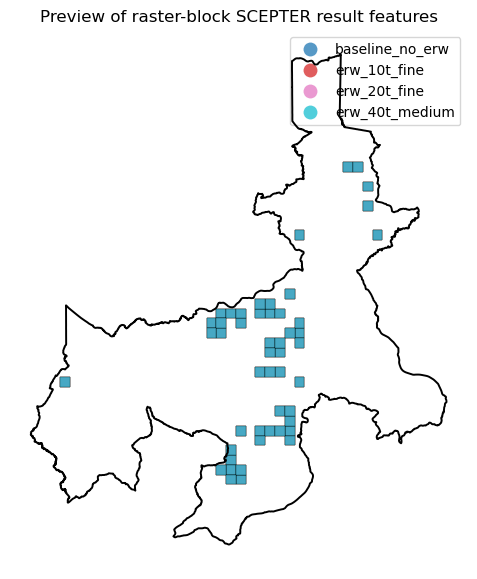

,model_unit_id,scenario_id,result_status,execution_status,area_ha,cropland_source,soil_map_texture_group,rainfall_months_used,geometry
0,mu_00001,baseline_no_erw,parsed,complete,1386.31,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.59108 1.0645, 31.59108 1.10717, 31.54842 1.10717, 31.54842 1.0645, 31.59108 1.0645))"
1,mu_00001,erw_10t_fine,parsed,complete,1386.31,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.59108 1.0645, 31.59108 1.10717, 31.54842 1.10717, 31.54842 1.0645, 31.59108 1.0645))"
2,mu_00001,erw_20t_fine,parsed,complete,1386.31,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.59108 1.0645, 31.59108 1.10717, 31.54842 1.10717, 31.54842 1.0645, 31.59108 1.0645))"
3,mu_00001,erw_40t_medium,parsed,complete,1386.31,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.59108 1.0645, 31.59108 1.10717, 31.54842 1.10717, 31.54842 1.0645, 31.59108 1.0645))"
4,mu_00002,baseline_no_erw,parsed,complete,1318.87,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.54842 0.63783, 31.54842 0.6805, 31.50575 0.6805, 31.50575 0.63783, 31.54842 0.63783))"
5,mu_00002,erw_10t_fine,parsed,complete,1318.87,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.54842 0.63783, 31.54842 0.6805, 31.50575 0.6805, 31.50575 0.63783, 31.54842 0.63783))"
6,mu_00002,erw_20t_fine,parsed,complete,1318.87,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.54842 0.63783, 31.54842 0.6805, 31.50575 0.6805, 31.50575 0.63783, 31.54842 0.63783))"
7,mu_00002,erw_40t_medium,parsed,complete,1318.87,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.54842 0.63783, 31.54842 0.6805, 31.50575 0.6805, 31.50575 0.63783, 31.54842 0.63783))"
8,mu_00003,baseline_no_erw,parsed,complete,1310.58,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.46308 1.14983, 31.46308 1.1925, 31.42042 1.1925, 31.42042 1.14983, 31.46308 1.14983))"
9,mu_00003,erw_10t_fine,parsed,complete,1310.58,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12","POLYGON ((31.46308 1.14983, 31.46308 1.1925, 31.42042 1.1925, 31.42042 1.14983, 31.46308 1.14983))"


In [5]:
preview_columns = [
    "model_unit_id",
    "scenario_id",
    "result_status",
    "execution_status",
    "area_ha",
    "cropland_source",
    "soil_map_texture_group",
    "rainfall_months_used",
]
preview_columns = [column for column in preview_columns if column in spatial_results.columns]
spatial_feature_preview = spatial_results[preview_columns + ["geometry"]].head(12).copy()

fig, ax = plt.subplots(figsize=(9, 7))
spatial_results.head(200).plot(
    ax=ax,
    column="scenario_id" if "scenario_id" in spatial_results.columns else None,
    categorical=True if "scenario_id" in spatial_results.columns else False,
    legend=True if "scenario_id" in spatial_results.columns else False,
    alpha=0.75,
    linewidth=0.2,
    edgecolor="black",
)
finish_map(ax, "Preview of raster-block SCEPTER result features")
plt.show()

spatial_feature_preview


## Select MRV Metrics

The metric names will depend on the final SCEPTER output parser. This cell prioritizes carbon retained/carbon stock metrics, then falls back to CO2 removal, weathering, and alkalinity columns when present.


In [6]:
CARBON_RETAINED_METRICS = [
    "dic_flux_carbon_equivalent_t",
    "carbon_retained_t",
    "carbon_retained_t_ha",
    "carbon_retention_t",
    "carbon_retention_t_ha",
    "carbon_stored_t",
    "carbon_storage_t",
    "soil_carbon_retained_t",
    "soil_organic_carbon_t",
    "soc_t",
    "retained_carbon_t",
]

CO2_REMOVAL_METRICS = [
    "dic_flux_co2_equivalent_t",
    "additional_co2_t",
    "co2_removal_t_ha",
    "co2_removal_t",
    "cumulative_co2_removal_t",
    "net_co2_removal_t",
]

PROCESS_METRICS = [
    "alkalinity_mol_ha",
    "weathering_rate",
]

PREFERRED_MAP_METRICS = CO2_REMOVAL_METRICS + CARBON_RETAINED_METRICS + PROCESS_METRICS
EXCLUDE_FALLBACK_NUMERIC = {
    "value",
    "cropland_pixels",
    "cropland_pixel_area_m2",
    "cropland_area_m2",
    "cropland_area_ha",
    "area_m2",
    "area_ha",
    "centroid_lon",
    "centroid_lat",
    "soil_ph",
    "cec_cmolc_kg",
    "clay_pct",
    "bulk_density_g_cm3",
    "soil_depth_cm",
    "temperature_c",
    "precipitation_mm_yr",
    "runoff_mm_yr",
    "basalt_application_t_ha",
    "basalt_d50_um",
    "simulation_years",
    "block_geometry_area_m2",
    "return_code",
    "elapsed_seconds",
}

available_metrics = [
    column for column in PREFERRED_MAP_METRICS
    if column in spatial_results.columns and pd.api.types.is_numeric_dtype(spatial_results[column])
]

if not available_metrics:
    numeric_candidates = [
        column for column in spatial_results.select_dtypes(include="number").columns
        if column not in EXCLUDE_FALLBACK_NUMERIC and not column.startswith("soil_map_")
    ]
    available_metrics = numeric_candidates[:3]

PRIMARY_METRIC = available_metrics[0] if available_metrics else None
CARBON_RETAINED_METRIC = next((metric for metric in CARBON_RETAINED_METRICS if metric in available_metrics), None)
print("Available MRV map metrics:", available_metrics)
print("Primary metric:", PRIMARY_METRIC or "not available yet; status maps will be generated")
print("Carbon retained metric:", CARBON_RETAINED_METRIC or "not available yet")


Available MRV map metrics: ['dic_flux_co2_equivalent_t', 'dic_flux_carbon_equivalent_t']
Primary metric: dic_flux_co2_equivalent_t
Carbon retained metric: dic_flux_carbon_equivalent_t


## Status And Scenario Tables

These tables show whether model runs were parsed successfully and whether any summary files are still missing.


In [7]:
status_summary = results.groupby(["scenario_id", "execution_status", "result_status"]).size().rename("run_count").reset_index()
status_summary_path = TABLE_DIR / "scepter_result_status_summary.csv"
status_summary.to_csv(status_summary_path, index=False)

provenance_summary = (
    spatial_results[required_provenance_columns]
    .drop_duplicates()
    .reset_index(drop=True)
)
provenance_summary_path = TABLE_DIR / "spatial_mrv_input_provenance.csv"
provenance_summary.to_csv(provenance_summary_path, index=False)

if PRIMARY_METRIC:
    scenario_metric_summary = spatial_results.groupby("scenario_id").agg(
        model_units=("model_unit_id", "nunique"),
        total_area_ha=("area_ha", "sum"),
        parsed_runs=("result_status", lambda values: int((values == "parsed").sum())),
        missing_summaries=("result_status", lambda values: int((values == "missing_summary").sum())),
        metric_mean=(PRIMARY_METRIC, "mean"),
        metric_sum=(PRIMARY_METRIC, "sum"),
    ).reset_index()
    scenario_metric_summary["metric"] = PRIMARY_METRIC
else:
    scenario_metric_summary = spatial_results.groupby("scenario_id").agg(
        model_units=("model_unit_id", "nunique"),
        total_area_ha=("area_ha", "sum"),
        parsed_runs=("result_status", lambda values: int((values == "parsed").sum())),
        missing_summaries=("result_status", lambda values: int((values == "missing_summary").sum())),
    ).reset_index()
    scenario_metric_summary["metric"] = "none_available"

scenario_metric_path = TABLE_DIR / "spatial_mrv_scenario_summary.csv"
scenario_metric_summary.to_csv(scenario_metric_path, index=False)

if CARBON_RETAINED_METRIC:
    carbon_retained_summary = spatial_results.groupby("scenario_id").agg(
        model_units=("model_unit_id", "nunique"),
        total_area_ha=("area_ha", "sum"),
        carbon_retained_mean=(CARBON_RETAINED_METRIC, "mean"),
        carbon_retained_sum=(CARBON_RETAINED_METRIC, "sum"),
    ).reset_index()
    carbon_retained_summary["metric"] = CARBON_RETAINED_METRIC
else:
    carbon_retained_summary = pd.DataFrame(
        columns=["scenario_id", "model_units", "total_area_ha", "carbon_retained_mean", "carbon_retained_sum", "metric"]
    )

carbon_retained_path = TABLE_DIR / "spatial_mrv_carbon_retained_summary.csv"
carbon_retained_summary.to_csv(carbon_retained_path, index=False)

status_summary, scenario_metric_summary, carbon_retained_summary, provenance_summary


(       scenario_id execution_status result_status  run_count
 0  baseline_no_erw         complete        parsed        100
 1     erw_10t_fine         complete        parsed        100
 2     erw_20t_fine         complete        parsed        100
 3   erw_40t_medium         complete        parsed        100,
        scenario_id  model_units  total_area_ha  parsed_runs  \
 0  baseline_no_erw          100       90763.12          100   
 1     erw_10t_fine          100       90763.12          100   
 2     erw_20t_fine          100       90763.12          100   
 3   erw_40t_medium          100       90763.12          100   
 
    missing_summaries  metric_mean  metric_sum                     metric  
 0                  0     -0.03874    -3.87402  dic_flux_co2_equivalent_t  
 1                  0     -0.03874    -3.87402  dic_flux_co2_equivalent_t  
 2                  0     -0.03874    -3.87402  dic_flux_co2_equivalent_t  
 3                  0     -0.03874    -3.87402  dic_flux_co2_eq

## Interpret Current Spatial Results

The current spatial layer is a parsed SCEPTER outcome surface for the AOI. Each scenario has one row per ESA cropland raster-block model unit, joined back to the soil, rainfall, and cropland inputs prepared in notebooks `03` and `04`.

Read the current maps like this:

- `baseline_no_erw`: no basalt amendment scenario for each cropland block.
- `erw_10t_fine`: 10 t/ha basalt scenario for the same cropland blocks.
- `erw_20t_fine`: 20 t/ha basalt scenario for the same cropland blocks.
- `erw_40t_medium`: 40 t/ha basalt scenario for the same cropland blocks.

The maps show the parsed SCEPTER metric across the AOI for each scenario, with the AOI boundary retained for geographic context.


In [8]:
scenario_order = ["baseline_no_erw", "erw_10t_fine", "erw_20t_fine", "erw_40t_medium"]
scenario_labels = {
    "baseline_no_erw": "Baseline: 0 t/ha",
    "erw_10t_fine": "ERW: 10 t/ha fine basalt",
    "erw_20t_fine": "ERW: 20 t/ha fine basalt",
    "erw_40t_medium": "ERW: 40 t/ha medium basalt",
}

scenario_application_t_ha = {
    "baseline_no_erw": 0.0,
    "erw_10t_fine": 10.0,
    "erw_20t_fine": 20.0,
    "erw_40t_medium": 40.0,
}

scenario_status_detail = (
    spatial_results.groupby(["scenario_id", "result_status"], dropna=False)
    .agg(
        model_units=("model_unit_id", "nunique"),
        total_area_ha=("area_ha", "sum"),
    )
    .reset_index()
)
scenario_status_detail["application_t_ha"] = scenario_status_detail["scenario_id"].map(scenario_application_t_ha)
scenario_status_detail["scenario_label"] = scenario_status_detail["scenario_id"].map(scenario_labels).fillna(scenario_status_detail["scenario_id"])
scenario_status_detail["scenario_id"] = pd.Categorical(scenario_status_detail["scenario_id"], categories=scenario_order, ordered=True)
scenario_status_detail = scenario_status_detail.sort_values(["scenario_id", "result_status"]).reset_index(drop=True)
scenario_status_detail["scenario_id"] = scenario_status_detail["scenario_id"].astype(str)

scenario_status_detail_path = TABLE_DIR / "spatial_mrv_scenario_status_detail.csv"
scenario_status_detail.to_csv(scenario_status_detail_path, index=False)
scenario_status_detail


,scenario_id,result_status,model_units,total_area_ha,application_t_ha,scenario_label
0,baseline_no_erw,parsed,100,90763.12,0.0,Baseline: 0 t/ha
1,erw_10t_fine,parsed,100,90763.12,10.0,ERW: 10 t/ha fine basalt
2,erw_20t_fine,parsed,100,90763.12,20.0,ERW: 20 t/ha fine basalt
3,erw_40t_medium,parsed,100,90763.12,40.0,ERW: 40 t/ha medium basalt


## Export Spatial Result Layer

This GeoPackage is the compact GIS handoff from the MRV workflow.


In [9]:
spatial_export_path = MAP_DIR / "spatial_mrv_scepter_results.gpkg"
spatial_results.to_file(spatial_export_path, layer="scepter_results", driver="GPKG")
spatial_export_path


PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_scepter_results.gpkg')

## Create Scenario Maps

Maps are exported as PNGs. If no numeric MRV metric exists yet, the notebook maps run status instead.


In [10]:
map_paths = []
scenario_ids = sorted(spatial_results["scenario_id"].dropna().unique()) if "scenario_id" in spatial_results.columns else ["all"]

for scenario_id in scenario_ids:
    scenario_gdf = spatial_results[spatial_results["scenario_id"] == scenario_id].copy()
    if scenario_gdf.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 8))
    if PRIMARY_METRIC:
        scenario_gdf.plot(
            column=PRIMARY_METRIC,
            ax=ax,
            legend=True,
            cmap="viridis",
            linewidth=0.1,
            edgecolor="black",
        )
        title = f"{scenario_id}: {PRIMARY_METRIC}"
    elif "result_status" in scenario_gdf.columns:
        scenario_gdf.plot(
            column="result_status",
            ax=ax,
            legend=True,
            categorical=True,
            linewidth=0.1,
            edgecolor="black",
        )
        title = f"{scenario_id}: result status"
    else:
        scenario_gdf.plot(ax=ax, color="#8ecae6", edgecolor="#023047", linewidth=0.1)
        title = f"{scenario_id}: model units"

    finish_map(ax, title)
    out_path = MAP_DIR / f"spatial_mrv_{scenario_id}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    map_paths.append(out_path)

map_paths


[PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_baseline_no_erw.png'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_erw_10t_fine.png'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_erw_20t_fine.png'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_erw_40t_medium.png')]

## Side-By-Side Scenario Status Maps

The panels below show the same ESA cropland raster-block model units under each parsed SCEPTER scenario: baseline, 10 t/ha, 20 t/ha, and 40 t/ha. The color represents the selected quantitative MRV metric where available, with status colors used only if parsed metrics are unavailable.


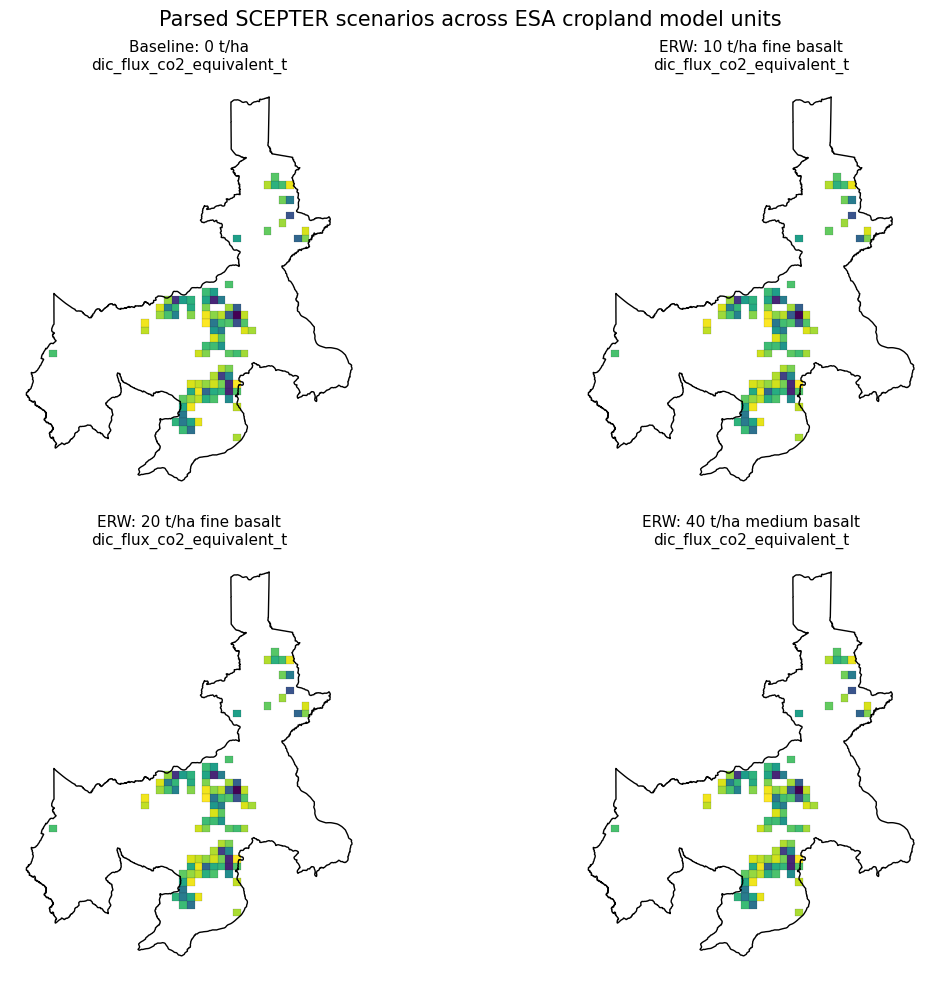

PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_scenario_status_grid.png')

In [11]:
scenario_status_grid_path = MAP_DIR / "spatial_mrv_scenario_status_grid.png"
status_palette = {
    "parsed": "#2a9d8f",
    "missing_summary": "#2b83ba",
    "failed": "#d7191c",
    "staged_not_executed": "#9e9e9e",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, scenario_id in zip(axes, scenario_order):
    scenario_gdf = spatial_results[spatial_results["scenario_id"] == scenario_id].copy()
    if scenario_gdf.empty:
        ax.set_title(scenario_labels.get(scenario_id, scenario_id))
        ax.set_axis_off()
        continue

    if PRIMARY_METRIC:
        scenario_gdf.plot(
            column=PRIMARY_METRIC,
            ax=ax,
            cmap="viridis",
            legend=False,
            linewidth=0.1,
            edgecolor="#263238",
        )
        subtitle = PRIMARY_METRIC
    else:
        scenario_gdf["status_color"] = scenario_gdf["result_status"].map(status_palette).fillna("#6c757d")
        scenario_gdf.plot(
            ax=ax,
            color=scenario_gdf["status_color"],
            linewidth=0.1,
            edgecolor="#263238",
        )
        status_counts = scenario_gdf["result_status"].value_counts(dropna=False).to_dict()
        subtitle = ", ".join(f"{key}: {value}" for key, value in status_counts.items())

    add_aoi_boundary(ax, linewidth=1.0)
    ax.set_title(f"{scenario_labels.get(scenario_id, scenario_id)}\n{subtitle}", fontsize=11)
    ax.set_axis_off()

for ax in axes[len(scenario_order):]:
    ax.set_axis_off()

fig.suptitle("Parsed SCEPTER scenarios across ESA cropland model units", fontsize=15)
fig.tight_layout()
fig.savefig(scenario_status_grid_path, dpi=220, bbox_inches="tight")
plt.show()

if scenario_status_grid_path not in map_paths:
    map_paths.append(scenario_status_grid_path)
scenario_status_grid_path


### Interpreting The Side-By-Side Scenario Maps

All four panels use the same ESA cropland model-unit geometry and the same AOI boundary. The visual pattern is therefore mainly a spatial screening result: it shows where cropland model units exist inside the selected districts and which units have parsed SCEPTER outputs. In this run, the status table reports 100 parsed runs per scenario and zero missing summaries, so the maps are complete for baseline, 10 t/ha, 20 t/ha, and 40 t/ha scenarios.

The mapped quantitative metric is `dic_flux_co2_equivalent_t`. The scenario summaries currently have the same aggregate values across all four scenarios: mean `-0.03874`, sum `-3.87402`, and total mapped cropland area `90,763.12 ha` per scenario. That similarity should be read as a limitation of this short-run SCEPTER execution, not as evidence that basalt application has no effect. The useful result at this stage is that the pipeline can carry cropland, rainfall, soil class, scenario dose, and parsed SCEPTER summaries back into spatial model units. A longer production-year run should be used before interpreting dose-response differences among 10, 20, and 40 t/ha.

This interpretation is consistent with the ERW literature: Beerling et al. (2020) frame cropland ERW as a scalable CO2-removal pathway but emphasize uncertainty in soil weathering rates and transfer of weathering products; Taylor et al. (2016) show the mechanism can matter at climate scale but is sensitive to application rate, mineralogy, and deployment assumptions; Reershemius et al. (2023) stress that robust MRV is a central barrier for translating modelled weathering into verified removals.


## Carbon Retained Map

When SCEPTER outputs include a carbon-retained or soil-carbon metric, this creates a dedicated map across all result features.

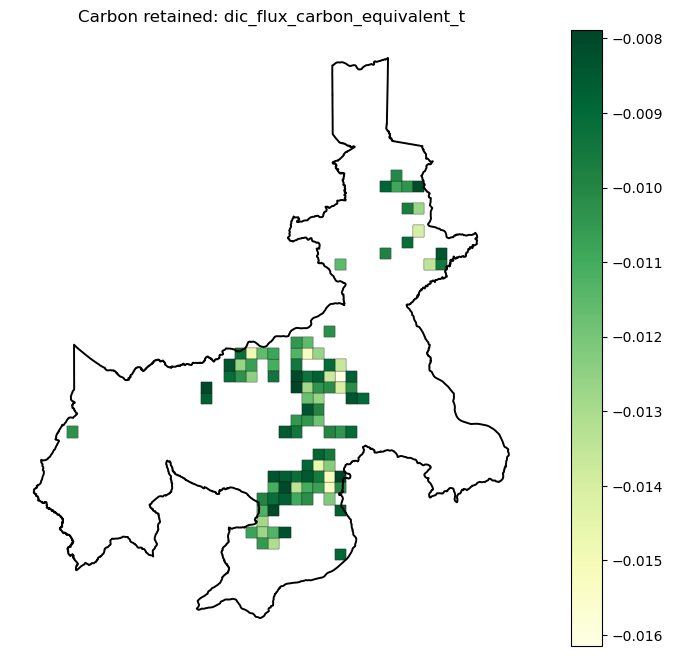

PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/maps/spatial_mrv/spatial_mrv_carbon_retained.png')

In [12]:
carbon_retained_map_path = None

if CARBON_RETAINED_METRIC:
    fig, ax = plt.subplots(figsize=(10, 8))
    spatial_results.plot(
        column=CARBON_RETAINED_METRIC,
        ax=ax,
        legend=True,
        cmap="YlGn",
        linewidth=0.1,
        edgecolor="black",
    )
    finish_map(ax, f"Carbon retained: {CARBON_RETAINED_METRIC}")
    carbon_retained_map_path = MAP_DIR / "spatial_mrv_carbon_retained.png"
    fig.savefig(carbon_retained_map_path, dpi=200, bbox_inches="tight")
    map_paths.append(carbon_retained_map_path)
    plt.show()
else:
    print("No carbon-retained metric found yet. Available numeric metrics are:")
    display(spatial_results.select_dtypes(include="number").columns.to_series().reset_index(drop=True).to_frame("numeric_column"))

carbon_retained_map_path


### Interpreting The Carbon Retained Map

The carbon retained map uses `dic_flux_carbon_equivalent_t`, which is the carbon-equivalent form of the parsed DIC flux metric. In the current outputs, each scenario has a mean value of `-0.010573` and a summed value of `-1.057291` across the 100 cropland model units. Because those totals are identical for baseline and the three ERW scenarios, this map should be treated as a spatial QA and baseline carbon-flux surface rather than a final carbon-removal claim.

Spatially, the strongest and weakest values cluster by cropland model unit, reflecting the shared input geography: ESA cropland blocks overlaid with HWSD2 soil texture groups and rainfall inputs. That is useful for MRV design because it highlights where field sampling, soil chemistry checks, or scenario-specific model diagnostics should be prioritized. It does not yet prove additional retained carbon from basalt dose. For that, notebook 05 needs a full-duration production run and notebook 06 should compute scenario-minus-baseline additionality once the parsed outputs diverge by dose.

Field and MRV studies show why this caution matters. Beerling et al. (2023) report measured carbon-removal and agronomic benefits from basalt application in a large Corn Belt field trial, while Reershemius et al. (2023) show that soil-based mass balance can validate ERW but needs careful chemical measurement to overcome signal-to-noise limits. In other words, the map is a strong geospatial MRV scaffold, but the carbon-retained values should be labelled preliminary until supported by full SCEPTER runs and, eventually, field observations.


### Research Context

- Beerling, D. J. et al. (2020). *Potential for large-scale CO2 removal via enhanced rock weathering with croplands*. Nature, 583, 242-248. https://doi.org/10.1038/s41586-020-2448-9
- Taylor, L. L. et al. (2016). *Enhanced weathering strategies for stabilizing climate and averting ocean acidification*. Nature Climate Change, 6, 402-406. https://doi.org/10.1038/nclimate2882
- Reershemius, T. et al. (2023). *Initial validation of a soil-based mass-balance approach for empirical monitoring of enhanced rock weathering rates*. Environmental Science & Technology. https://doi.org/10.1021/acs.est.3c03609
- Beerling, D. J. et al. (2023). *Enhanced weathering in the U.S. Corn Belt delivers carbon removal with agronomic benefits*. arXiv:2307.05343. https://doi.org/10.48550/arXiv.2307.05343


## Scenario Comparison Figure

This chart compares scenarios using carbon retained when available, otherwise the primary MRV metric, otherwise available run counts.


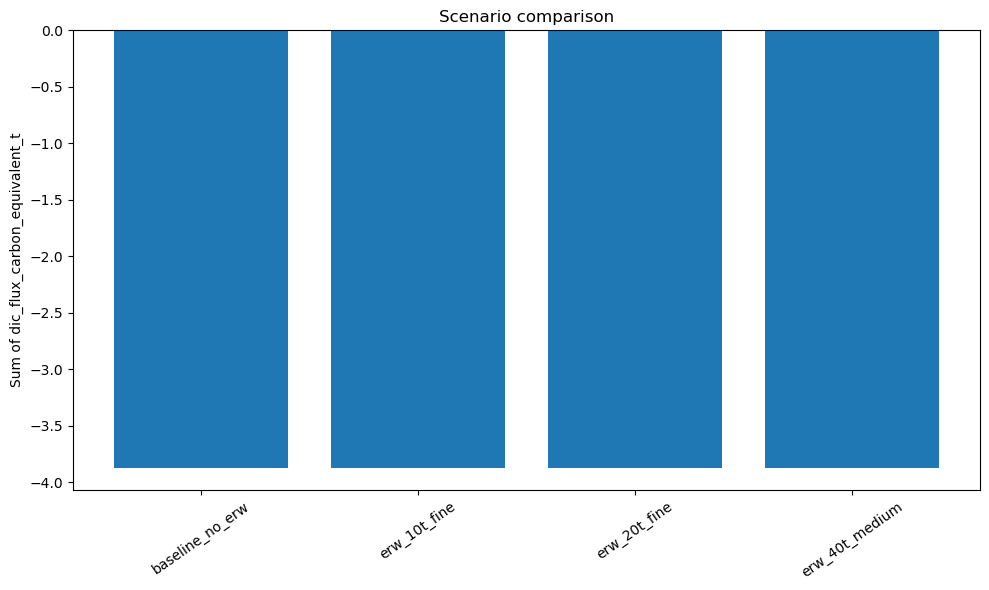

PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/figures/spatial_mrv/spatial_mrv_scenario_comparison.png')

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison_metric = CARBON_RETAINED_METRIC or PRIMARY_METRIC

if comparison_metric and "metric_sum" in scenario_metric_summary.columns:
    plot_data = scenario_metric_summary.sort_values("metric_sum", ascending=False)
    ax.bar(plot_data["scenario_id"], plot_data["metric_sum"])
    ax.set_ylabel(f"Sum of {comparison_metric}")
    ax.set_title("Scenario comparison")
else:
    plot_data = status_summary.groupby("scenario_id")["run_count"].sum().reset_index()
    ax.bar(plot_data["scenario_id"], plot_data["run_count"])
    ax.set_ylabel("Run count")
    ax.set_title("Scenario run counts")

ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
comparison_path = FIGURE_DIR / "spatial_mrv_scenario_comparison.png"
fig.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()
comparison_path


## District/AOI MRV Summary

This table is intentionally compact: it is the kind of summary that can go into a methods note or MRV report appendix.


In [14]:
report_summary = {
    "spatial_result_rows": int(len(spatial_results)),
    "scenario_count": int(len(scenario_ids)),
    "primary_metric": PRIMARY_METRIC or "none_available",
    "carbon_retained_metric": CARBON_RETAINED_METRIC or "none_available",
    "parsed_runs": int((results["result_status"] == "parsed").sum()) if "result_status" in results.columns else 0,
    "missing_summaries": int((results["result_status"] == "missing_summary").sum()) if "result_status" in results.columns else 0,
    "cropland_source": spatial_results["cropland_source"].dropna().astype(str).iloc[0],
    "soil_map_labels": ", ".join(sorted(spatial_results["soil_map_texture_group"].dropna().astype(str).unique())),
    "rainfall_months_used": spatial_results["rainfall_months_used"].dropna().astype(str).iloc[0],
    "scenario_status_table": str(scenario_status_detail_path.relative_to(PROJECT_ROOT)) if "scenario_status_detail_path" in globals() else "not available",
}

if CARBON_RETAINED_METRIC and not carbon_retained_summary.empty:
    report_summary["carbon_retained_total"] = float(carbon_retained_summary["carbon_retained_sum"].sum())
    report_summary["carbon_retained_metric_units"] = CARBON_RETAINED_METRIC

report_summary_df = pd.DataFrame([report_summary])
report_summary_path = TABLE_DIR / "spatial_mrv_report_summary.csv"
report_summary_df.to_csv(report_summary_path, index=False)
report_summary_df


,spatial_result_rows,scenario_count,primary_metric,carbon_retained_metric,parsed_runs,missing_summaries,cropland_source,soil_map_labels,rainfall_months_used,scenario_status_table,carbon_retained_total,carbon_retained_metric_units
0,400,4,dic_flux_co2_equivalent_t,dic_flux_carbon_equivalent_t,400,0,ESA WorldCover cropland mask,"Clay, Clay loam, Loam","2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",data/outputs/tables/spatial_mrv/spatial_mrv_scenario_status_detail.csv,-4.229165,dic_flux_carbon_equivalent_t


## Write Markdown Report

The report is deliberately short and operational: it records what exists, what was mapped, and what remains blocked.


In [15]:
report_path = REPORT_DIR / "spatial_mrv_report.md"
map_list = chr(10).join(f"- `{path.relative_to(PROJECT_ROOT)}`" for path in map_paths) or "- No maps generated."
metric_text = PRIMARY_METRIC or "No numeric MRV metric available yet."
carbon_metric_text = CARBON_RETAINED_METRIC or "No carbon-retained metric available yet."

report = f"""# Spatial MRV Report

## Inputs

- Spatial SCEPTER results: `{SPATIAL_RESULTS_PATH.relative_to(PROJECT_ROOT)}`
- Flat SCEPTER results: `{RESULTS_TABLE_PATH.relative_to(PROJECT_ROOT)}`
- Scenario summary: `{SCENARIO_SUMMARY_PATH.relative_to(PROJECT_ROOT) if SCENARIO_SUMMARY_PATH.exists() else 'not available'}`
- Cropland source: `{report_summary['cropland_source']}`
- Soil map labels in parsed results: `{report_summary['soil_map_labels']}`
- Rainfall months used: `{report_summary['rainfall_months_used']}`
- AOI boundary: `{AOI_PATH.relative_to(PROJECT_ROOT)}`

## Result Status

- Spatial result rows: {report_summary['spatial_result_rows']:,}
- Scenario count: {report_summary['scenario_count']:,}
- Parsed SCEPTER runs: {report_summary['parsed_runs']:,}
- Missing SCEPTER summaries: {report_summary['missing_summaries']:,}
- Primary mapped metric: `{metric_text}`
- Carbon retained metric: `{carbon_metric_text}`

## Outputs

- Spatial result layer: `{spatial_export_path.relative_to(PROJECT_ROOT)}`
- Scenario summary table: `{scenario_metric_path.relative_to(PROJECT_ROOT)}`
- Carbon retained summary table: `{carbon_retained_path.relative_to(PROJECT_ROOT)}`
- Status summary table: `{status_summary_path.relative_to(PROJECT_ROOT)}`
- Scenario status detail table: `{scenario_status_detail_path.relative_to(PROJECT_ROOT) if "scenario_status_detail_path" in globals() else "not available"}`
- Input provenance table: `{provenance_summary_path.relative_to(PROJECT_ROOT)}`
- Report summary table: `{report_summary_path.relative_to(PROJECT_ROOT)}`
- Scenario comparison figure: `{comparison_path.relative_to(PROJECT_ROOT)}`

## Maps

{map_list}

## Notes

If parsed SCEPTER runs are zero or scenario summaries are missing, rerun notebook `05` with a valid external SCEPTER command, then rerun notebooks `06` and `07` to refresh the quantitative carbon-retained and CO2 removal maps.
"""

report_path.write_text(report, encoding="utf-8")
print(report_path)
print(report[:2200])


/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/outputs/reports/spatial_mrv/spatial_mrv_report.md
# Spatial MRV Report

## Inputs

- Spatial SCEPTER results: `data/scepter_runs/outputs/extracted/scepter_results_by_model_unit.gpkg`
- Flat SCEPTER results: `data/scepter_runs/outputs/extracted/scepter_results_long.csv`
- Scenario summary: `data/scepter_runs/outputs/extracted/scepter_scenario_summary.csv`
- Cropland source: `ESA WorldCover cropland mask`
- Soil map labels in parsed results: `Clay, Clay loam, Loam`
- Rainfall months used: `2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12`
- AOI boundary: `data/processed/boundaries/selected_districts_aoi.geojson`

## Result Status

- Spatial result rows: 400
- Scenario count: 4
- Parsed SCEPTER runs: 400
- Missing SCEPTER summaries: 0
- Primary mapped metric: `dic_flux_co2_equivalent_t`
- Carbon retained metric: `dic_flux_carbon_equivalent_t`

## Outputs

- S

## Outputs From This Notebook

This notebook writes spatial MRV products under `data/outputs/`:

- `data/outputs/maps/spatial_mrv/spatial_mrv_scepter_results.gpkg`: GIS-ready model-unit/scenario result layer.
- `data/outputs/maps/spatial_mrv/spatial_mrv_{scenario_id}.png`: one map per scenario.
- `data/outputs/maps/spatial_mrv/spatial_mrv_scenario_status_grid.png`: side-by-side baseline, 10t, 20t, and 40t scenario status maps.
- `data/outputs/maps/spatial_mrv/spatial_mrv_carbon_retained.png`: dedicated carbon-retained map when a carbon metric exists.
- `data/outputs/figures/spatial_mrv/spatial_mrv_scenario_comparison.png`: scenario comparison chart.
- `data/outputs/tables/spatial_mrv/scepter_result_status_summary.csv`: run/result status counts.
- `data/outputs/tables/spatial_mrv/spatial_mrv_scenario_status_detail.csv`: baseline, 10t, 20t, and 40t result status by scenario.
- `data/outputs/tables/spatial_mrv/spatial_mrv_scenario_summary.csv`: scenario-level MRV metric summary.
- `data/outputs/tables/spatial_mrv/spatial_mrv_carbon_retained_summary.csv`: scenario-level carbon-retained summary when available.
- `data/outputs/tables/spatial_mrv/spatial_mrv_input_provenance.csv`: ESA cropland, HWSD2 soil-map/default, CHIRPS rainfall, and runoff provenance.
- `data/outputs/tables/spatial_mrv/spatial_mrv_report_summary.csv`: compact report header metrics.
- `data/outputs/reports/spatial_mrv/spatial_mrv_report.md`: Markdown report for review.

The next step is uncertainty/sensitivity analysis: vary application rate, particle size, runoff, soil chemistry, and model parameters to produce uncertainty intervals around the spatial MRV estimates.
